# Numerical solver for the discrete space and structured model

### Setup

Import the model and paramater class from the file model_solver

In [2]:
%load_ext autoreload
%autoreload 2

# Standard Imports
import numpy as np
import matplotlib.pyplot as plt

# Your Custom Import
from model_solver import Params, MacrophageModel
from model_solver_no_heaviside import MacrophageModelNoHeaviside

### Parameters and execution

In [3]:
# Define your parameters
p = Params(
    M=100, N=100, kplus=3, kminus=1, beta=2, D_min=0.1, gamma=0.2,
    sigma_b=0.004, sigma_max=0.4, V_tot=100000, v_max=10, theta=10, debug=True
)

t_final = 10.0

In [4]:
# Instantiate the model
model = MacrophageModel(p)

# Setup Time
t_span = (0.0, t_final)
t_eval = np.linspace(t_span[0], t_span[1], 500)
u0 = 1/(model.p.N * model.p.M) * np.ones((model.p.M + 1, model.p.N + 1))  # Initial condition: uniform distribution
y0 = u0.ravel()  # Flatten the initial condition for the solver

# Run the solver!
print("Starting solver...")
U, sol = model.solve(t_span, t_eval)
print(f"Solver finished successfully: {sol.success}")

# Extract all data
results = model.compute_diagnostics(U)

Starting solver...
Solver finished successfully: True


### Plotting and analysis

In [5]:
# Define time points to plot the results
time_points = [0.1, 0.5, 1.0, 1.5, t_final]

# 1. Choose a sequential colormap (e.g., 'Blues', 'Reds', 'Greens', 'Purples')
cmap = plt.get_cmap('Blues')
cmap_no_H = plt.get_cmap('Reds')

# 2. Generate the colors. 
# We map from 0.3 to 1.0 so the "lightest" color isn't completely white and invisible!
colors = cmap(np.linspace(0.3, 1.0, len(time_points)))
colors_no_H = cmap_no_H(np.linspace(0.3, 1.0, len(time_points)))

#### Spatial profiles

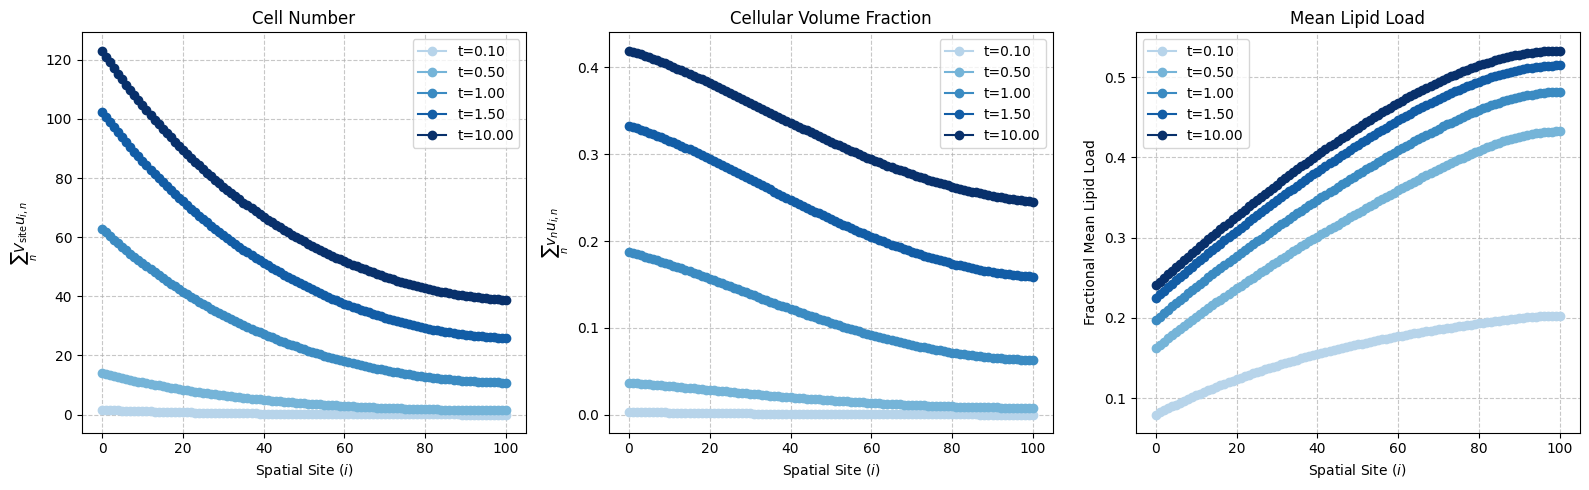

In [6]:
# Plot the cellular volume fraction, the cell density and mean lipid loads
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3. Use 'enumerate' to get an index (j) to grab the right color for each loop
for j, time in enumerate(time_points):
    # Find the index of the closest time point in the solution
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]   
    
    # Grab the specific color for this time point
    c = colors[j]
    
    # Add the 'color=c' argument to your plots
    axes[1].plot(model.i_array, results["spatial"]["volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    
    axes[0].plot(model.i_array, results["spatial"]["macrophage_number"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    
    axes[2].plot(model.i_array, results["spatial"]["mean_lipid_load"][idx, :]/model.p.N, 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)

# Format the plots
axes[1].set_title("Cellular Volume Fraction")
axes[1].set_xlabel("Spatial Site ($i$)")
axes[1].set_ylabel(r"$\sum_n v_n u_{i,n}$")

axes[0].set_title("Cell Number")
axes[0].set_xlabel("Spatial Site ($i$)")
axes[0].set_ylabel(r"$\sum_n V_{\text{site}} u_{i,n}$")

axes[2].set_title("Mean Lipid Load")
axes[2].set_xlabel("Spatial Site ($i$)")
axes[2].set_ylabel("Fractional Mean Lipid Load")

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Structure profiles

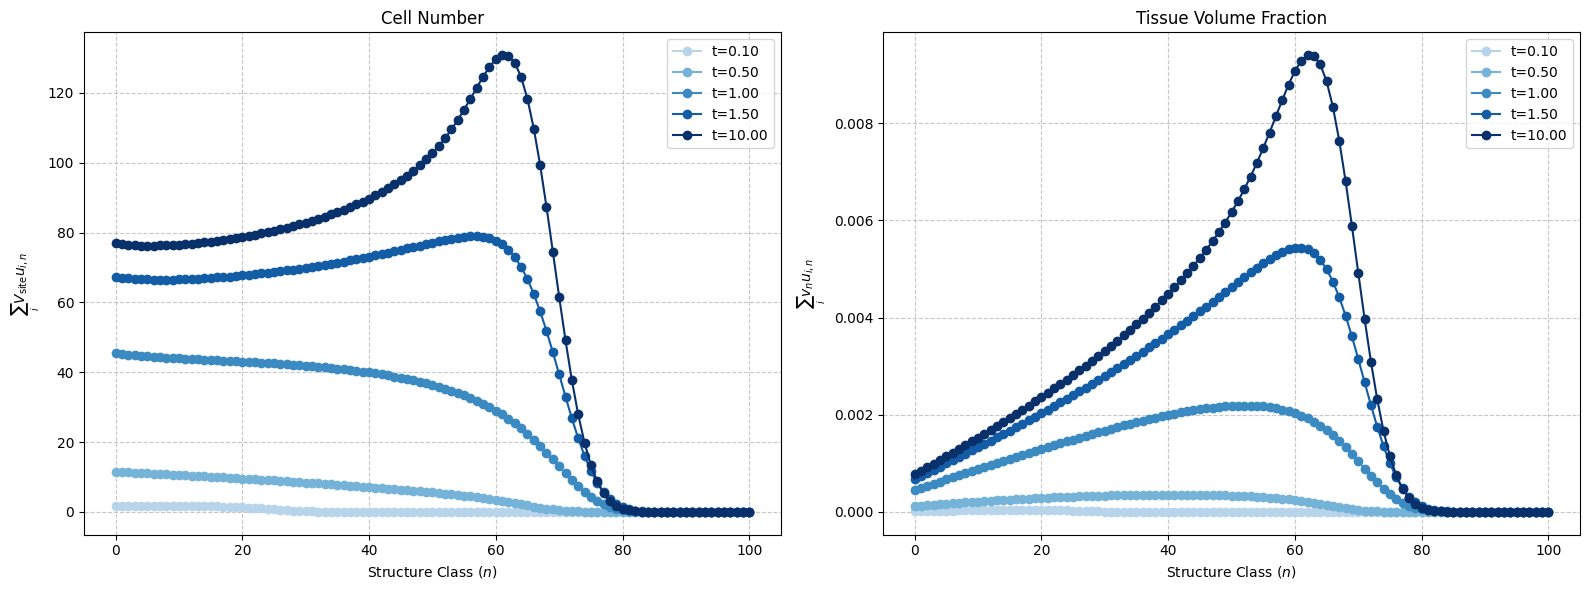

In [7]:
# Plot the cellular volume fraction, the cell density and mean lipid loads
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use 'enumerate' to get an index (j) to grab the right color for each loop
for j, time in enumerate(time_points):
    # Find the index of the closest time point in the solution
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]   
    
    # Grab the specific color for this time point
    c = colors[j]
    
    # Add the 'color=c' argument to your plots
    axes[0].plot(model.n_array, results["structure"]["macrophage_number"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    
    axes[1].plot(model.n_array, results["structure"]["tissue_volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)

# Format the plots
axes[0].set_title("Cell Number")
axes[0].set_xlabel("Structure Class ($n$)")
axes[0].set_ylabel(r"$\sum_i V_{\text{site}}u_{i,n}$")

axes[1].set_title("Tissue Volume Fraction")
axes[1].set_xlabel("Structure Class ($n$)")
axes[1].set_ylabel(r"$\sum_i v_n u_{i,n}$")

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

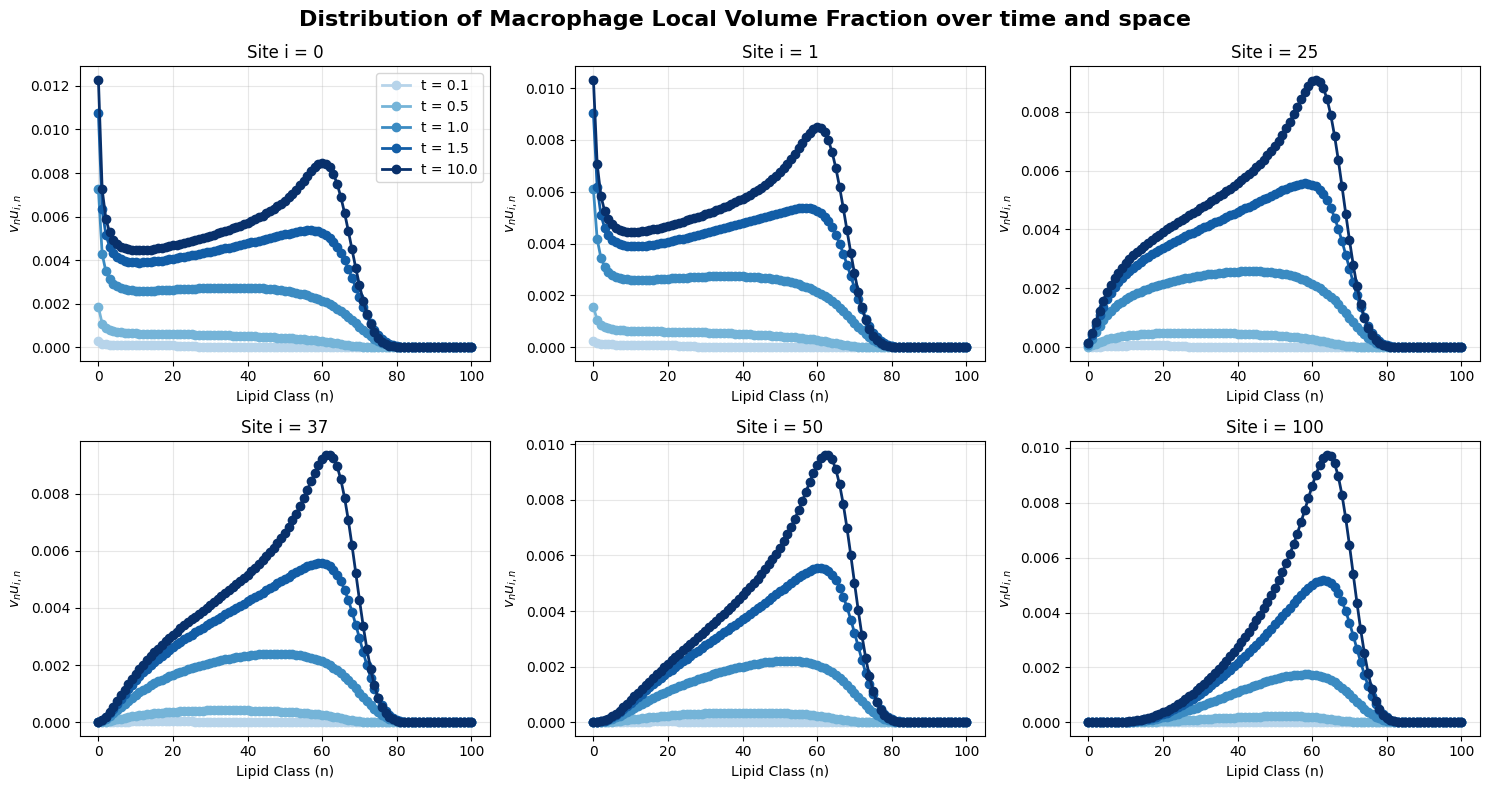

In [8]:
import math

# Pick a few spatial points to plot
spatial_sites_to_plot = [0, 1, int(p.M * 0.25), int(p.M * 0.37), int(p.M * 0.5), p.M]
num_plots = len(spatial_sites_to_plot)

# 1. Dynamically calculate grid size
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# 2. Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 3. Loop through the sites and plot them
# Renamed 'idx' to 'plot_idx' to avoid the bug
for plot_idx, site in enumerate(spatial_sites_to_plot):
    ax = axes[plot_idx]
    
    # Ensure we don't ask for a site larger than the grid
    safe_site = min(site, p.M)

    # Use 'enumerate' to get 'j' so we can pick the matching color
    for j, target_t in enumerate(time_points):
        
        # Renamed the time index to 't_idx' so it doesn't break the outer loop
        t_idx = np.argmin(np.abs(sol.t - target_t))
        actual_t = sol.t[t_idx]
        
        # Grab the specific color for this line
        c = colors[j]
    
        ax.plot(model.n_array, U[t_idx, safe_site, :] * model.v, 
                label=f"t = {actual_t:.1f}", linewidth=2, marker='o', color=c)
        
    ax.set_title(f"Site i = {safe_site}")
    ax.set_xlabel("Lipid Class (n)")
    ax.set_ylabel(r"$v_n u_{i,n}$")
    ax.grid(True, alpha=0.3)
    
    # Pro-tip: Only put the legend on the very first subplot so it isn't repeated 6 times!
    if plot_idx == 0:
        ax.legend()

# 4. Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Distribution of Macrophage Local Volume Fraction over time and space", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Total profiles

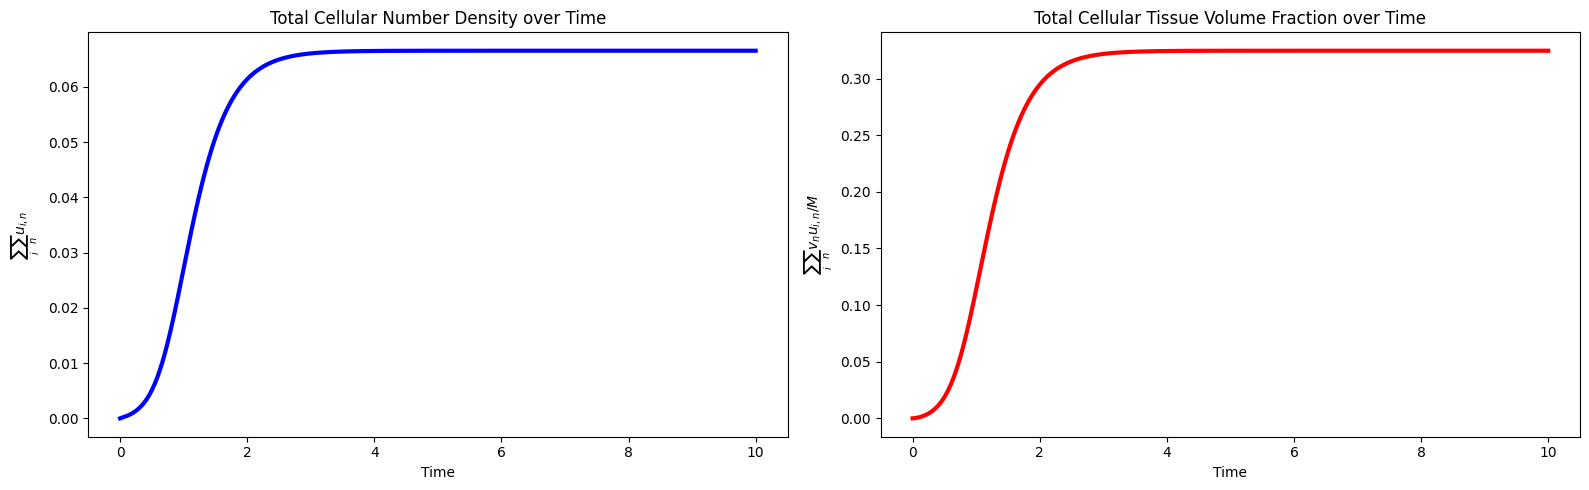

In [9]:
# Plot total cell density and tissue volume fraction over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sol.t, results["totals"]["average_cell_density"], linewidth=3, color='blue')
axes[0].set_title("Total Cellular Number Density over Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"$\sum_i\sum_n u_{i,n}$ ")

axes[1].plot(sol.t, results["totals"]["tissue_volume_fraction"], linewidth=3, color='red')
axes[1].set_title("Total Cellular Tissue Volume Fraction over Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$\sum_i\sum_n v_n u_{i,n}/M$ ")

for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.show()

#### Heatmaps

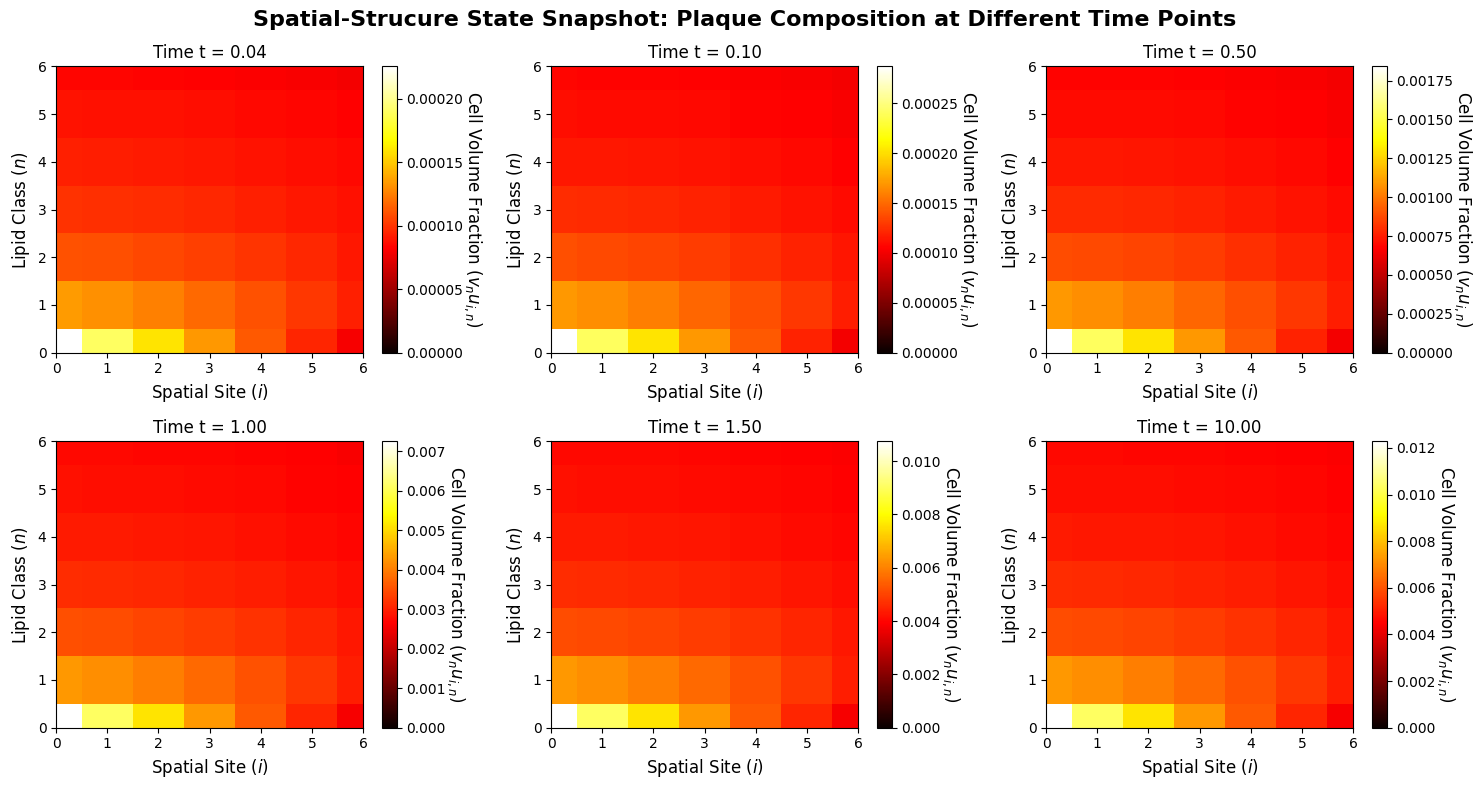

In [24]:
# Plot the heatmap of the local macrophage volume fraction at different time points
time_points_for_heatmap = [0.05, 0.1, 0.5, 1.0, 1.5, t_final]

num_plots = len(time_points_for_heatmap)
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for plot_idx, time in enumerate(time_points_for_heatmap):
    ax = axes[plot_idx]
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]

    mesh = ax.pcolormesh(model.i_array, model.n_array, (U[idx, :, :] * model.v).T,
                     cmap='hot', shading='auto') # hot, OrRd, Reds

    # Add the Colorbar so we can read the values
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Cell Volume Fraction ($v_n u_{i,n}$)", rotation=270, labelpad=15, fontsize=12)

    # Format the Plot
    ax.set_title(f"Time t = {actual_t:.2f}")
    ax.set_xlabel("Spatial Site ($i$)", fontsize=12)
    ax.set_ylabel("Lipid Class ($n$)", fontsize=12)

    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)

# Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Spatial-Strucure State Snapshot: Plaque Composition at Different Time Points", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Check boundary conditions

#### (0,0) corner

$\varepsilon=$0.01
$\delta =$ 0.01


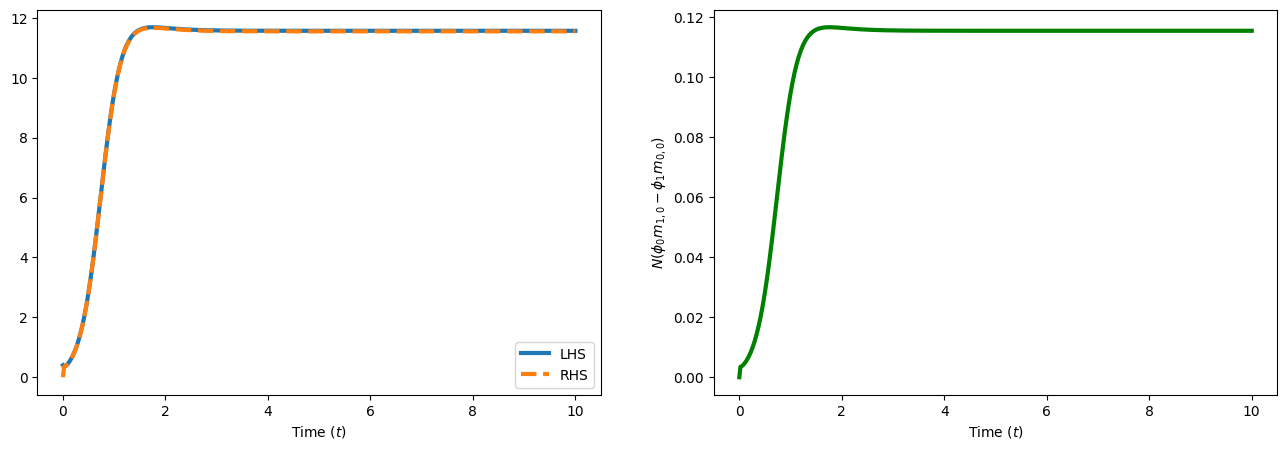

In [11]:
# Balancing source term + uptaking with the diffusion term at (0,0)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

VLt = model.compute_VL(U)
gt =  p.sigma_b + p.sigma_max *VLt / (1.0 + VLt)
phi = model.compute_phi(U)
continuum_BC = gt * phi[:,0] / p.beta 

# i=0, n=0
lhs = p.M * gt * phi[:, 0] - p.N * p.kplus * model.n_decay[0] * phi[:, 0] * U[:, 0, 0] 
rhs = p.M**2 * (phi[:, 0] * U[:, 1, 0] - phi[:, 1] * U[:, 0, 0])

diffusion = p.N * (phi[:, 0] * U[:, 1, 0] - phi[:, 1] * U[:, 0, 0])

# # i=1
# lhs = - p.N * p.kplus * model.n_decay[0] * phi[:, 1] * U[:, 1, 0] 
# rhs = p.M**2 * (phi[:, 1] * (U[:, 0, 0] + U[:, 2, 0]) - (phi[:, 2] + phi[:, 0]) * U[:, 1, 0])

# # n=1
# lhs =  p.N * p.kplus * phi[:, 0] * (model.n_decay[0] * U[:, 0, 0] - model.n_decay[1] * U[:, 0, 1] )
# rhs = p.M**2 * (p.D_min + (1 - p.D_min)) * model.n_decay[1] * (phi[:, 0] * U[:, 1, 1] - phi[:, 1] * U[:, 0, 1])

# Plot evolution of u_{0,0} compared to the evolution of the continuum BC
axes[0].plot(sol.t, lhs, label="LHS", linewidth=3)
axes[0].plot(sol.t, -rhs, label="RHS", linewidth=3, linestyle='--')
print(r"$\varepsilon=$" + str(1/p.N))
print(r"$\delta =$ " + str(1/p.M))
axes[0].set_xlabel("Time ($t$)")
axes[0].legend()

axes[1].plot(sol.t, abs(diffusion), linewidth=3, color='green')
axes[1].set_ylabel(r"$N(\phi_0 m_{1,0} - \phi_1 m_{0,0})$")
axes[1].set_xlabel("Time ($t$)")

plt.show()

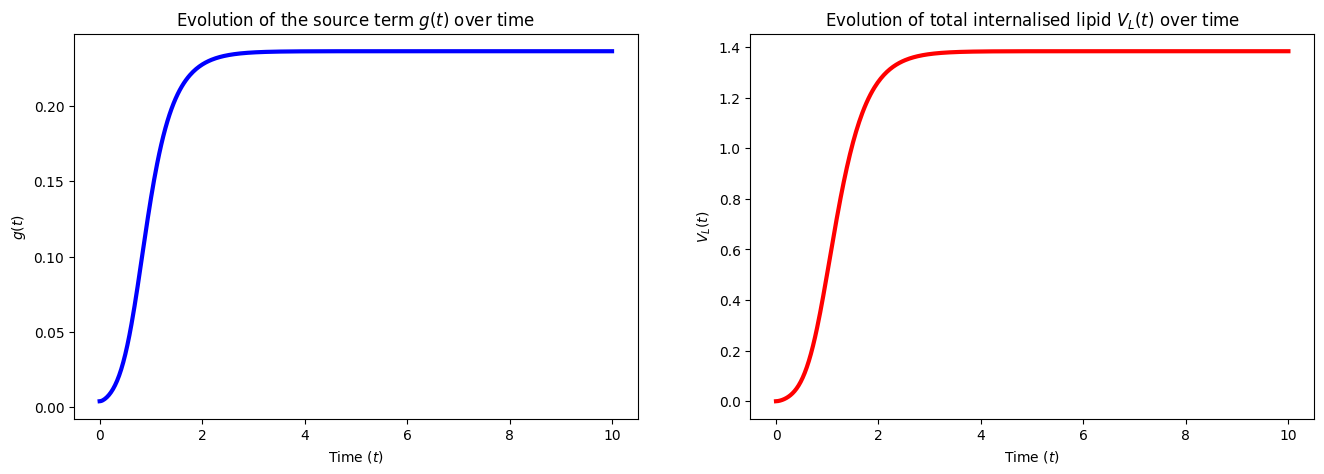

In [12]:
# Plot g(t) the evolution of the source term over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(sol.t, gt, label="g(t)", linewidth=3, color='blue')
axes[0].set_title("Evolution of the source term $g(t)$ over time")
axes[0].set_xlabel("Time ($t$)")
axes[0].set_ylabel("$g(t)$")

axes[1].plot(sol.t, VLt, linewidth=3, color='red')
axes[1].set_title("Evolution of total internalised lipid $V_L(t)$ over time")
axes[1].set_xlabel("Time ($t$)")
axes[1].set_ylabel("$V_L(t)$")

plt.show()

#### x=0 side

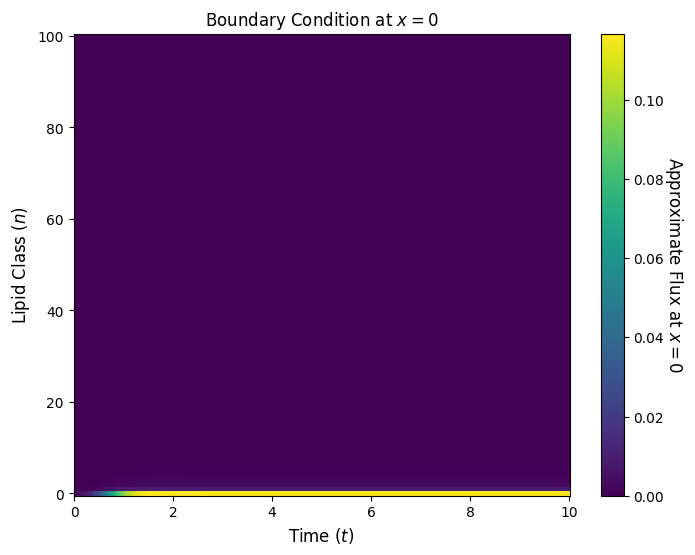

In [13]:
# Manually check the flux at j=0 to check if there is no flux
phi = results["spatial"]["phi"]
approx_flux = - (p.D_min + (1 - p.D_min) * model.n_decay) * p.M * (((phi[:,1]+phi[:,0])/2)[:, None] * (U[:, 1, :] - U[:, 0, :]) - (U[:, 0 ,:] + U[:, 1, :])/2 * (phi[:, 1] - phi[:, 0])[:, None])

plt.figure(figsize=(8, 6))

mesh = plt.pcolormesh(sol.t, model.n_array[0:p.N+1], approx_flux[:, 0:p.N+1].T,
                     cmap='viridis', shading='auto') # hot, OrRd, Reds

# Add the Colorbar so we can read the values
cbar = plt.colorbar(mesh)
cbar.set_label("Approximate Flux at $x=0$", rotation=270, labelpad=15, fontsize=12)

# Format the Plot
plt.xlabel("Time ($t$)", fontsize=12)
plt.ylabel("Lipid Class ($n$)", fontsize=12)
plt.title("Boundary Condition at $x=0$")

plt.show()

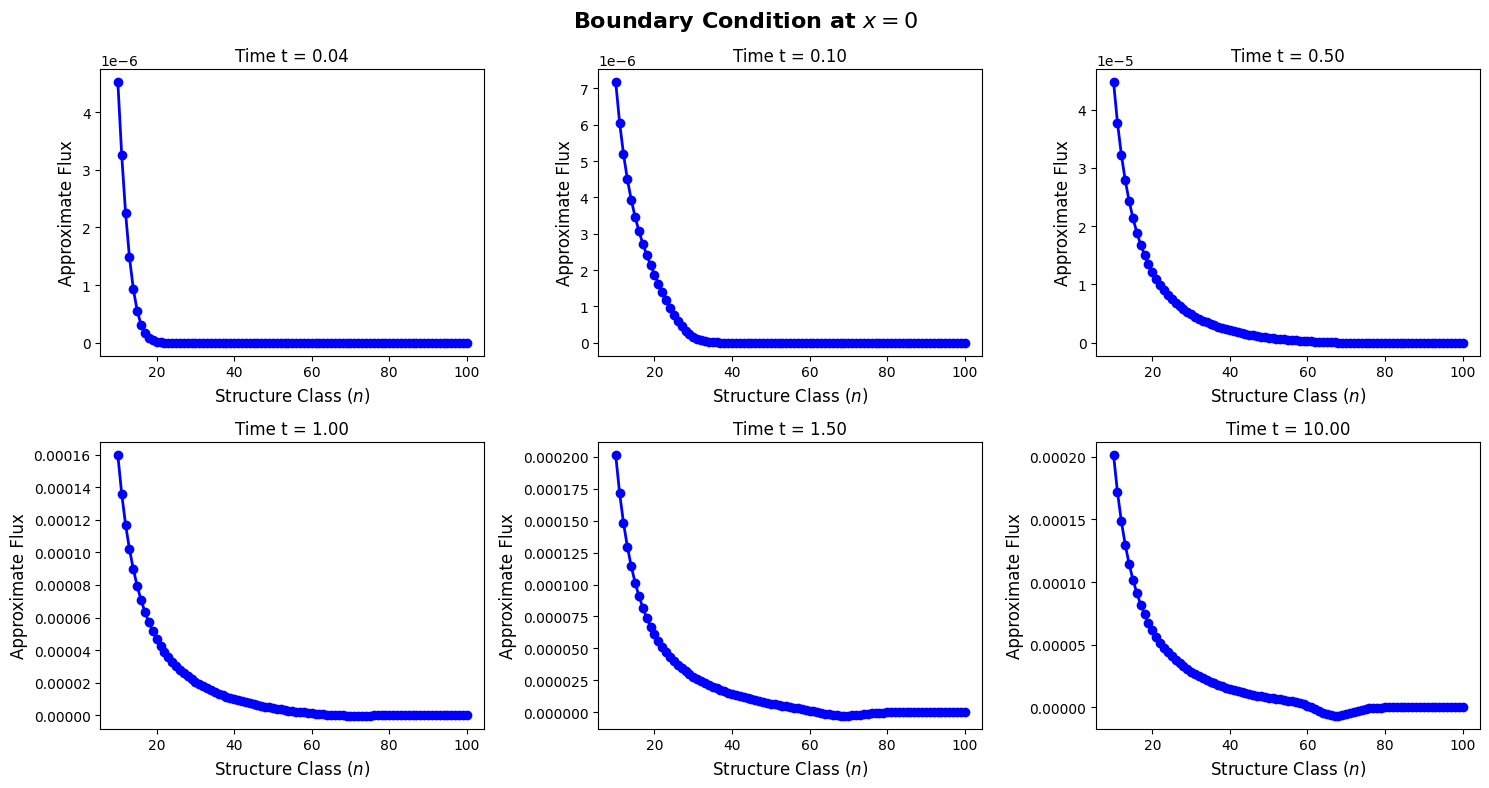

In [14]:
num_plots = len(time_points_for_heatmap)
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for plot_idx, time in enumerate(time_points_for_heatmap):
    ax = axes[plot_idx]
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]

    ax.plot(model.n_array[10:p.N+1], approx_flux[idx, 10:p.N+1], label=f"t = {actual_t:.2f}", linewidth=2, marker='o', color='blue')  

    # Format the Plot
    ax.set_title(f"Time t = {actual_t:.2f}")
    ax.set_xlabel("Structure Class ($n$)", fontsize=12)
    ax.set_ylabel("Approximate Flux", fontsize=12)

    #ax.set_xlim(0, 6)
    #ax.set_ylim(0, 6)

# Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Boundary Condition at $x=0$", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### x=1 side

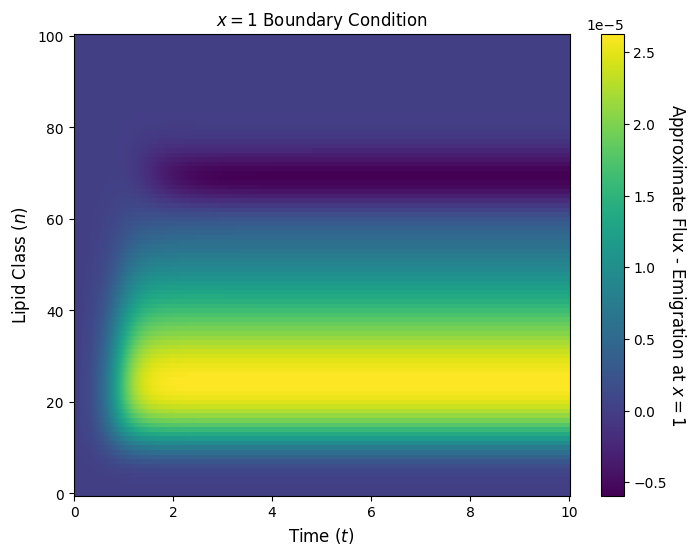

In [15]:
# Manually check the flux at j=J
phi = results["spatial"]["phi"]
approx_flux = - (p.D_min + (1 - p.D_min) * model.n_decay) * p.M * (((phi[:,p.M-1]+phi[:,p.M])/2)[:, None] * (U[:, p.M, :] - U[:, p.M-1, :]) - (U[:, p.M-1 ,:] + U[:, p.M, :])/2 * (phi[:, p.M] - phi[:, p.M-1])[:, None])
emigration = p.gamma * (p.D_min + (1 - p.D_min) * model.n_decay) * U[:, -1, :]

plt.figure(figsize=(8, 6))

mesh = plt.pcolormesh(sol.t, model.n_array[0:p.N+1], (approx_flux - emigration)[:, 0:p.N+1].T,
                     cmap='viridis', shading='auto') # hot, OrRd, Reds

# Add the Colorbar so we can read the values
cbar = plt.colorbar(mesh)
cbar.set_label("Approximate Flux - Emigration at $x=1$", rotation=270, labelpad=15, fontsize=12)

# Format the Plot
plt.xlabel("Time ($t$)", fontsize=12)
plt.ylabel("Lipid Class ($n$)", fontsize=12)
plt.title("$x=1$ Boundary Condition")

plt.show()

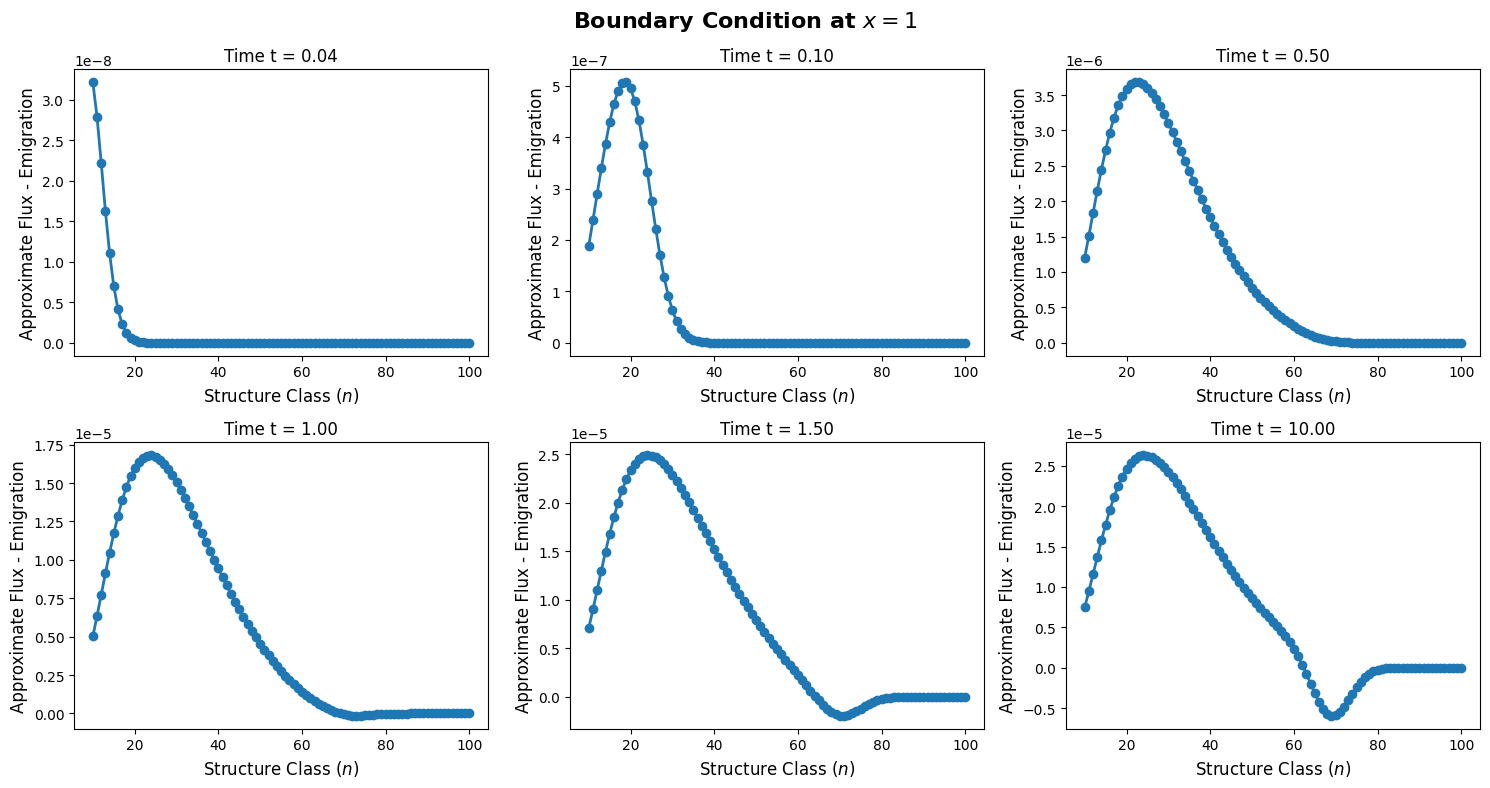

In [16]:
num_plots = len(time_points_for_heatmap)
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for plot_idx, time in enumerate(time_points_for_heatmap):
    ax = axes[plot_idx]
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]

    ax.plot(model.n_array[10:p.N+1], (approx_flux-emigration)[idx, 10:p.N+1], label=f"t = {actual_t:.2f}", linewidth=2, marker='o')  

    # Format the Plot
    ax.set_title(f"Time t = {actual_t:.2f}")
    ax.set_xlabel("Structure Class ($n$)", fontsize=12)
    ax.set_ylabel("Approximate Flux - Emigration", fontsize=12)

    #ax.set_xlim(0, 6)
    #ax.set_ylim(0, 6)

# Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Boundary Condition at $x=1$", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### s=0 side

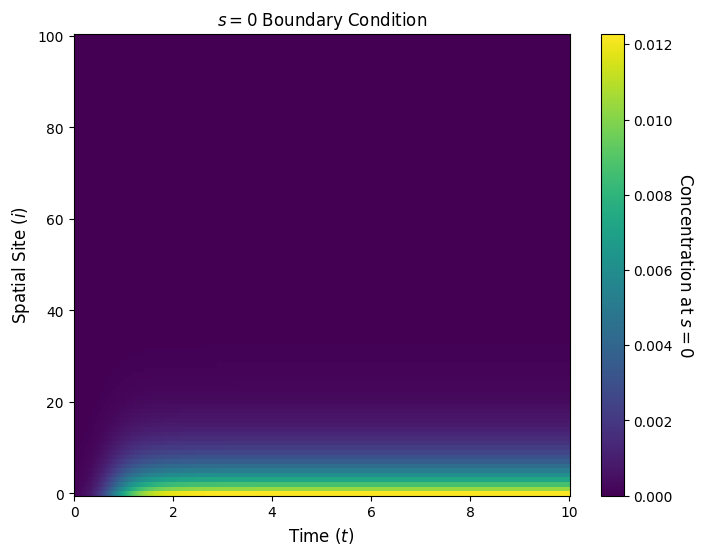

In [17]:
plt.figure(figsize=(8, 6))

mesh = plt.pcolormesh(sol.t, model.i_array[0:p.M+1], U[:, 0:p.M+1, 0].T,
                     cmap='viridis', shading='auto') # hot, OrRd, Reds

# Add the Colorbar so we can read the values
cbar = plt.colorbar(mesh)
cbar.set_label("Concentration at $s=0$", rotation=270, labelpad=15, fontsize=12)

# Format the Plot
plt.xlabel("Time ($t$)", fontsize=12)
plt.ylabel("Spatial Site ($i$)", fontsize=12)
plt.title("$s=0$ Boundary Condition")

plt.show()

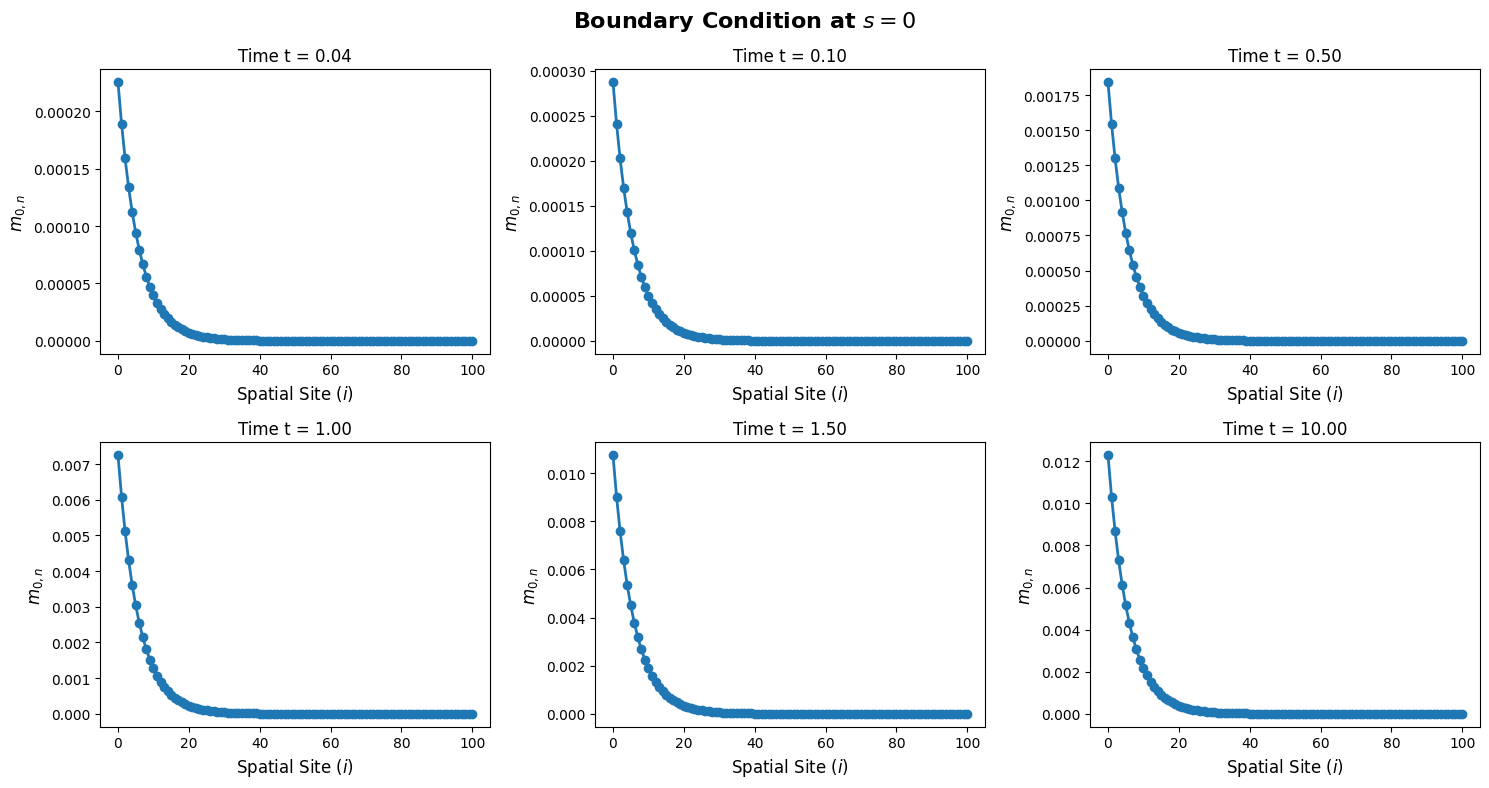

In [18]:
num_plots = len(time_points_for_heatmap)
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for plot_idx, time in enumerate(time_points_for_heatmap):
    ax = axes[plot_idx]
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]

    ax.plot(model.i_array[0:p.M+1], U[idx, 0:p.M+1, 0], label=f"t = {actual_t:.2f}", linewidth=2, marker='o')  

    # Format the Plot
    ax.set_title(f"Time t = {actual_t:.2f}")
    ax.set_xlabel("Spatial Site ($i$)", fontsize=12)
    ax.set_ylabel("$m_{0,n}$", fontsize=12)

    #ax.set_xlim(0, 6)
    #ax.set_ylim(0, 6)

# Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Boundary Condition at $s=0$", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### s=1 side

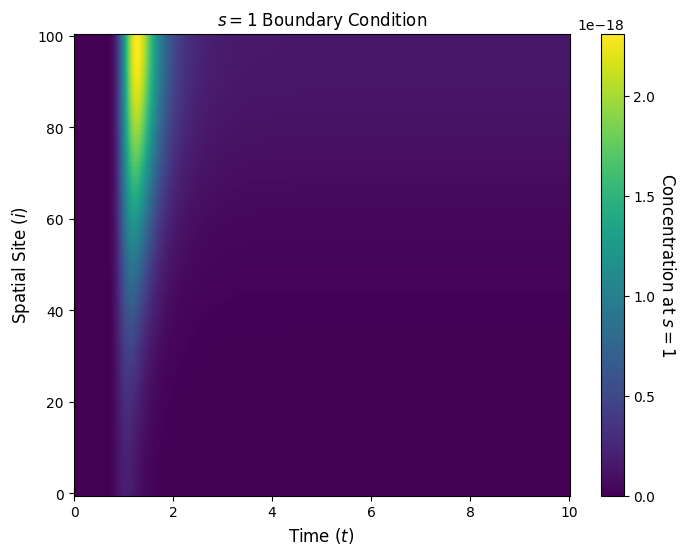

In [19]:
plt.figure(figsize=(8, 6))

mesh = plt.pcolormesh(sol.t, model.i_array[0:p.M+1], U[:, 0:p.M+1, p.N].T,
                     cmap='viridis', shading='auto') # hot, OrRd, Reds

# Add the Colorbar so we can read the values
cbar = plt.colorbar(mesh)
cbar.set_label("Concentration at $s=1$", rotation=270, labelpad=15, fontsize=12)

# Format the Plot
plt.xlabel("Time ($t$)", fontsize=12)
plt.ylabel("Spatial Site ($i$)", fontsize=12)
plt.title("$s=1$ Boundary Condition")

plt.show()

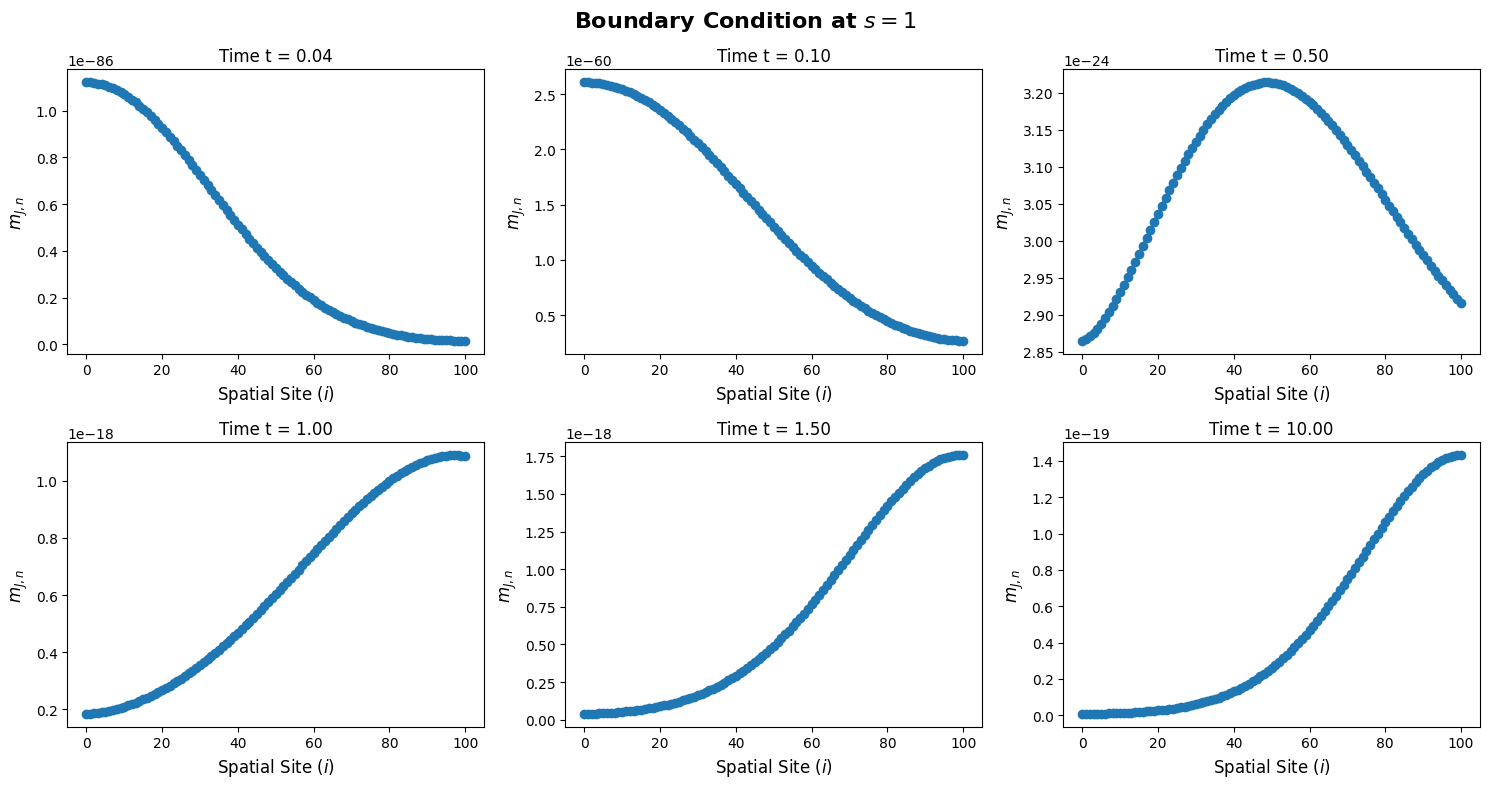

In [20]:
num_plots = len(time_points_for_heatmap)
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for plot_idx, time in enumerate(time_points_for_heatmap):
    ax = axes[plot_idx]
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]

    ax.plot(model.i_array[0:p.M+1], U[idx, 0:p.M+1, p.N], label=f"t = {actual_t:.2f}", linewidth=2, marker='o')  

    # Format the Plot
    ax.set_title(f"Time t = {actual_t:.2f}")
    ax.set_xlabel("Spatial Site ($i$)", fontsize=12)
    ax.set_ylabel("$m_{J,n}$", fontsize=12)

    #ax.set_xlim(0, 6)
    #ax.set_ylim(0, 6)

# Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle("Boundary Condition at $s=1$", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Corners

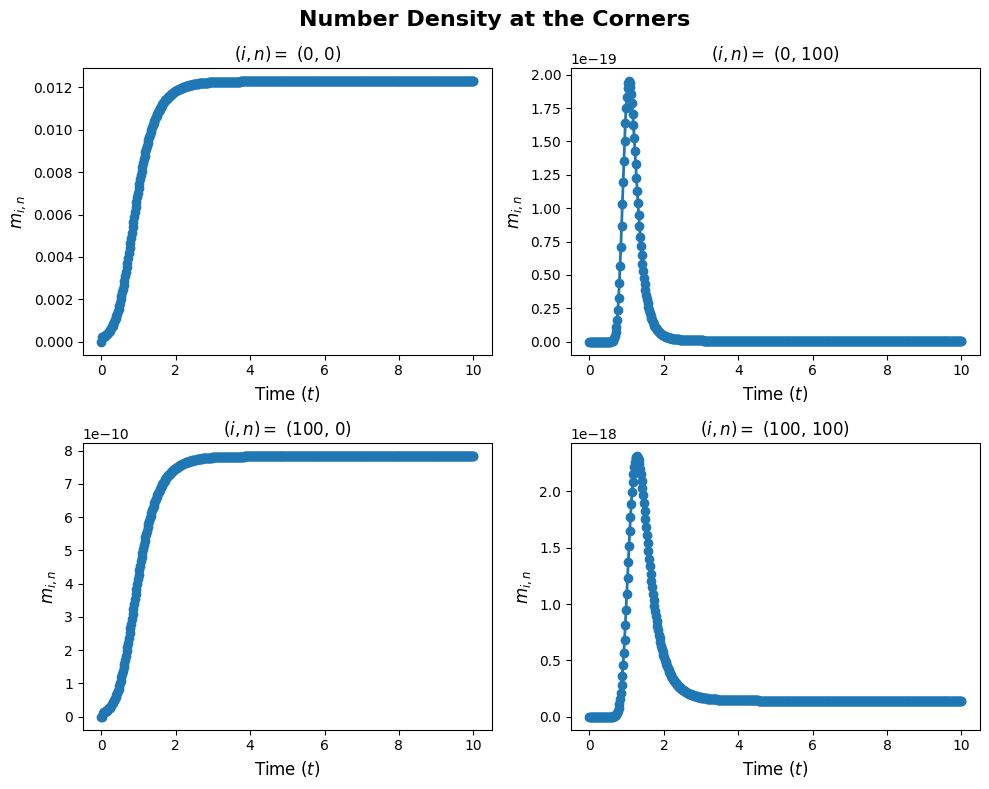

In [21]:
# Plotting the solution at the 4 corners
# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

corners = [(0, 0), (0, p.N), (p.M, 0), (p.M, p.N)]

axes = axes.flatten()

for idx in range(len(corners)):
    ax = axes[idx]

    i_idx, n_idx = corners[idx]

    ax.plot(sol.t, U[:, i_idx, n_idx], label=f"$(i,n) =$ {corners[idx]}", linewidth=2, marker='o')  

    # Format the Plot
    ax.set_title(f"$(i,n) =$ {corners[idx]}")
    ax.set_xlabel("Time ($t$)", fontsize=12)
    ax.set_ylabel("$m_{i,n}$", fontsize=12)



# Add title and automatically adjust layout
fig.suptitle("Number Density at the Corners", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


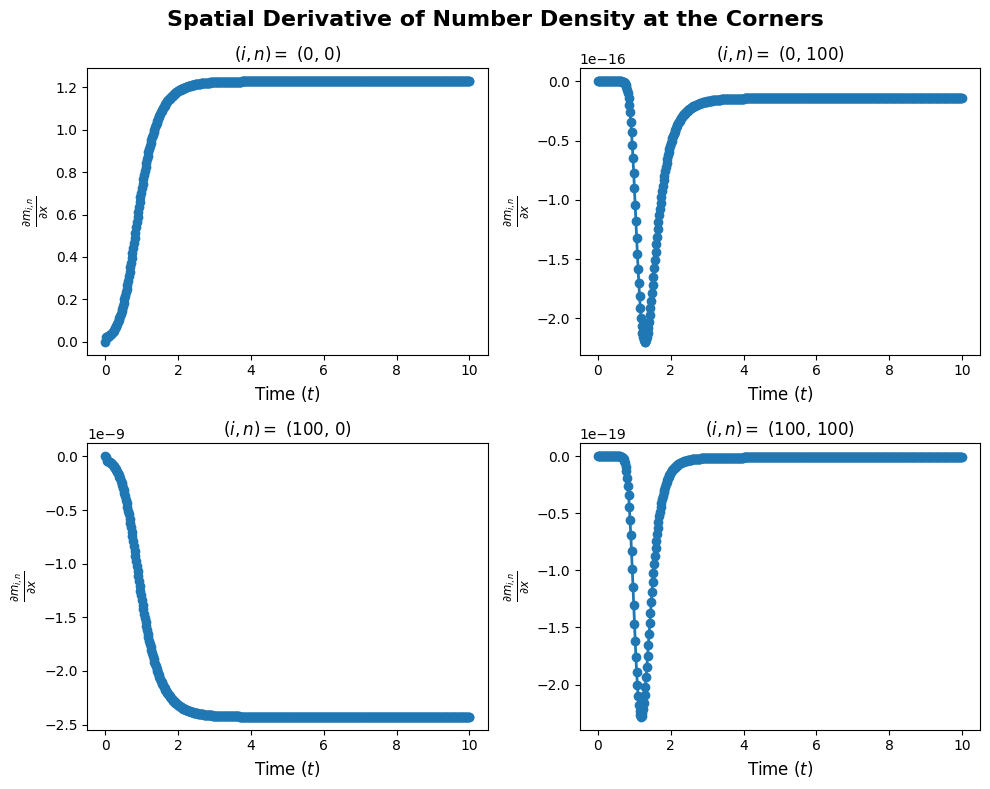

In [22]:
# Plotting the derivative of the solution at the 4 corners
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5 * 2, 4 * 2))
axes = axes.flatten()

for idx in range(len(corners)):
    ax = axes[idx]

    i_idx, n_idx = corners[idx]

    if i_idx == 1:

        approx_derivative = p.M * (U[:, i_idx+1, n_idx] - U[:, i_idx, n_idx])
    
    else:  
        approx_derivative = p.M * (U[:, i_idx, n_idx] - U[:, i_idx-1, n_idx])

    ax.plot(sol.t, approx_derivative, label=f"$(i,n) =$ {corners[idx]}", linewidth=2, marker='o')  

    # Format the Plot
    ax.set_title(f"$(i,n) =$ {corners[idx]}")
    ax.set_xlabel("Time ($t$)", fontsize=12)
    ax.set_ylabel(r"$\frac{\partial m_{i,n}}{\partial x}$", fontsize=12)



# Add title and automatically adjust layout
fig.suptitle("Spatial Derivative of Number Density at the Corners", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Compare results with and without Heavisde function

In [23]:
# Solve the model without the Heavisde function
model_no_H = MacrophageModelNoHeaviside(p)

# Run the solver!
print("Starting solver...")
U_no_H, sol_no_h = model_no_H.solve(t_span, t_eval)
print(f"Solver finished successfully: {sol_no_h.success}")

# Extract all data
results_no_H = model_no_H.compute_diagnostics(U_no_H)

Starting solver...


KeyboardInterrupt: 

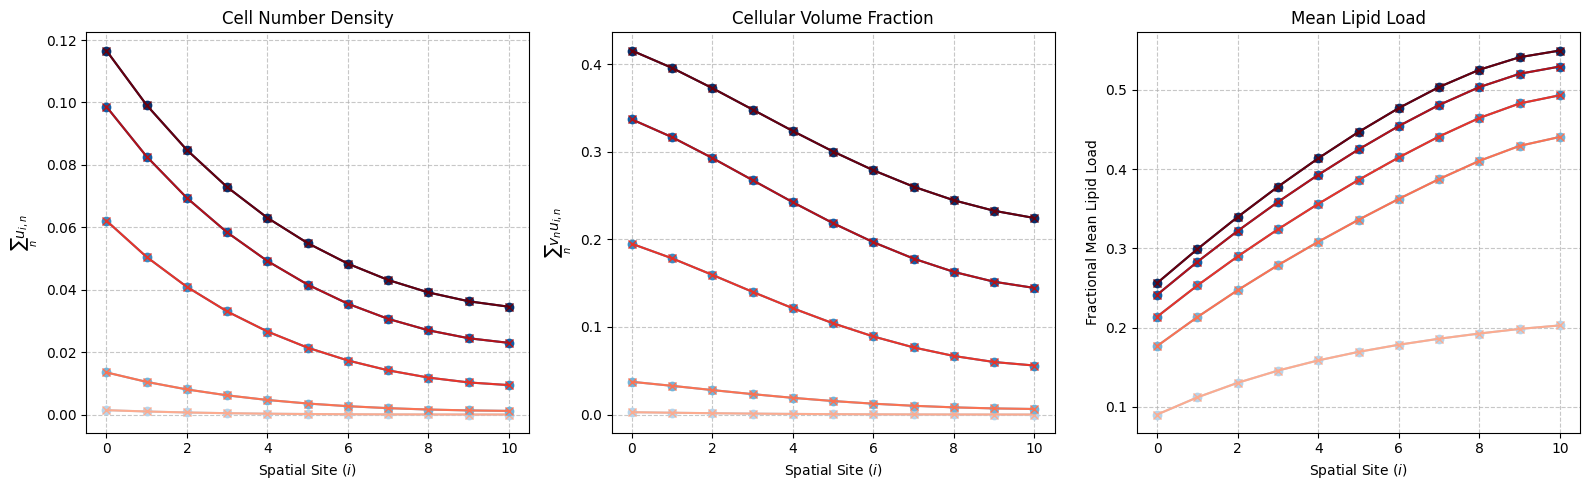

In [ ]:
# Plot the cellular volume fraction, the cell density and mean lipid loads
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3. Use 'enumerate' to get an index (j) to grab the right color for each loop
for j, time in enumerate(time_points):
    # Find the index of the closest time point in the solution
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]   
    
    # Grab the specific color for this time point
    c = colors[j]
    c_no_H = colors_no_H[j]
    
    # Add the 'color=c' argument to your plots
    axes[1].plot(model.i_array, results["spatial"]["volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    axes[1].plot(model.i_array, results_no_H["spatial"]["volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='x', markersize=6, color=c_no_H)
    
    axes[0].plot(model.i_array, results["spatial"]["cell_density"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    axes[0].plot(model.i_array, results_no_H["spatial"]["cell_density"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='x', markersize=6, color=c_no_H)
    
    axes[2].plot(model.i_array, results["spatial"]["mean_lipid_load"][idx, :]/model.p.N, 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    axes[2].plot(model.i_array, results_no_H["spatial"]["mean_lipid_load"][idx, :]/model.p.N, 
                 label=f"t={actual_t:.2f}", marker='x', markersize=6, color=c_no_H)

# Format the plots
axes[1].set_title("Cellular Volume Fraction")
axes[1].set_xlabel("Spatial Site ($i$)")
axes[1].set_ylabel(r"$\sum_n v_n u_{i,n}$")

axes[0].set_title("Cell Number Density")
axes[0].set_xlabel("Spatial Site ($i$)")
axes[0].set_ylabel(r"$\sum_n u_{i,n}$")

axes[2].set_title("Mean Lipid Load")
axes[2].set_xlabel("Spatial Site ($i$)")
axes[2].set_ylabel("Fractional Mean Lipid Load")

for ax in axes:
    #ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

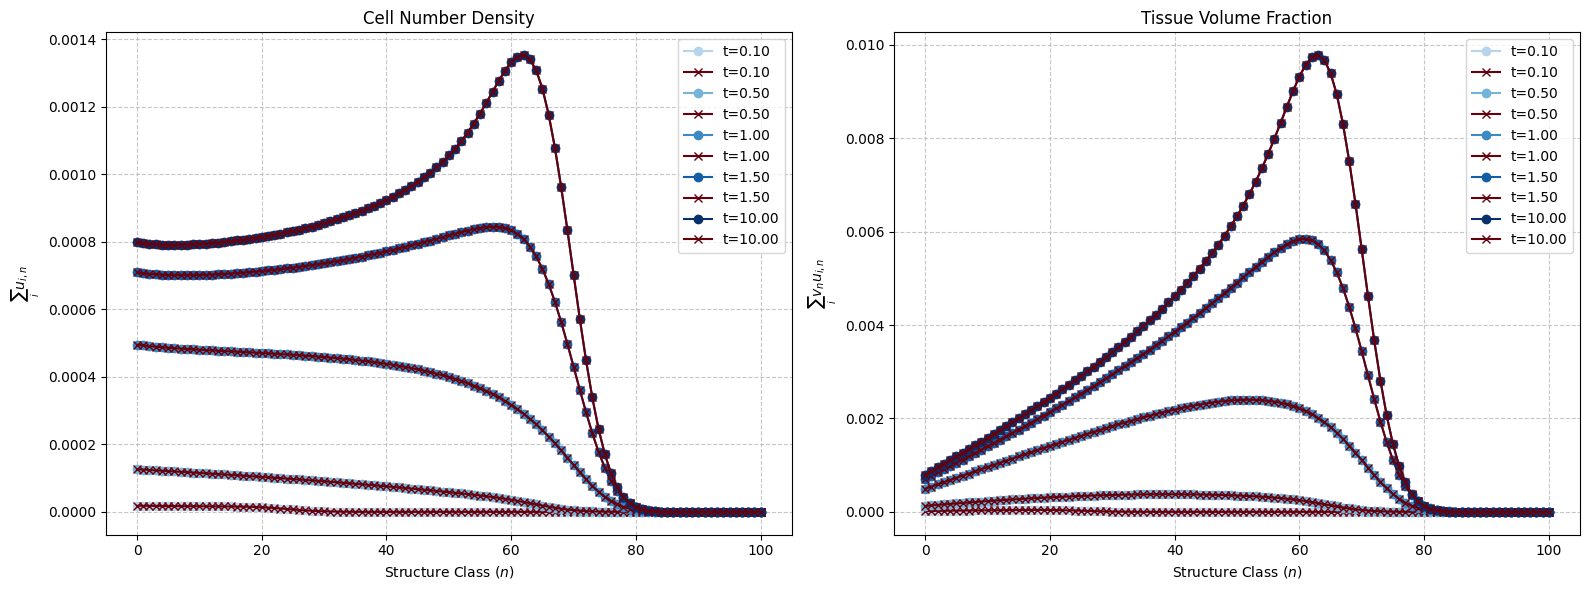

In [ ]:
# Plot the cellular volume fraction, the cell density and mean lipid loads
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use 'enumerate' to get an index (j) to grab the right color for each loop
for j, time in enumerate(time_points):
    # Find the index of the closest time point in the solution
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]   
    
    # Grab the specific color for this time point
    c = colors[j]
    c_no_H
    
    # Add the 'color=c' argument to your plots
    axes[0].plot(model.n_array, results["structure"]["average_cell_density"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    axes[0].plot(model.n_array, results_no_H["structure"]["average_cell_density"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='x', markersize=6, color=c_no_H)
    
    axes[1].plot(model.n_array, results["structure"]["tissue_volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='o', markersize=6, color=c)
    axes[1].plot(model.n_array, results_no_H["structure"]["tissue_volume_fraction"][idx, :], 
                 label=f"t={actual_t:.2f}", marker='x', markersize=6, color=c_no_H)

# Format the plots
axes[0].set_title("Cell Number Density")
axes[0].set_xlabel("Structure Class ($n$)")
axes[0].set_ylabel(r"$\sum_i u_{i,n}$")

axes[1].set_title("Tissue Volume Fraction")
axes[1].set_xlabel("Structure Class ($n$)")
axes[1].set_ylabel(r"$\sum_i v_n u_{i,n}$")

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()